# Ecommerce Data Analysis Project
### Customer Behavior, Pricing & Return Insights

**Dataset:** 1M+ Ecommerce Transactions
             **Goal:** Analyze Customer Behvior, returns, pricing patterns,and delivery performance

## Project Overview
This project explores a large scale e-commerce dataset containing over 1million transactions.
I Analyze:
- Customer Purchase Behavior
- Returns patterns
- Product pricing and discount effects
- seller and delivery performance

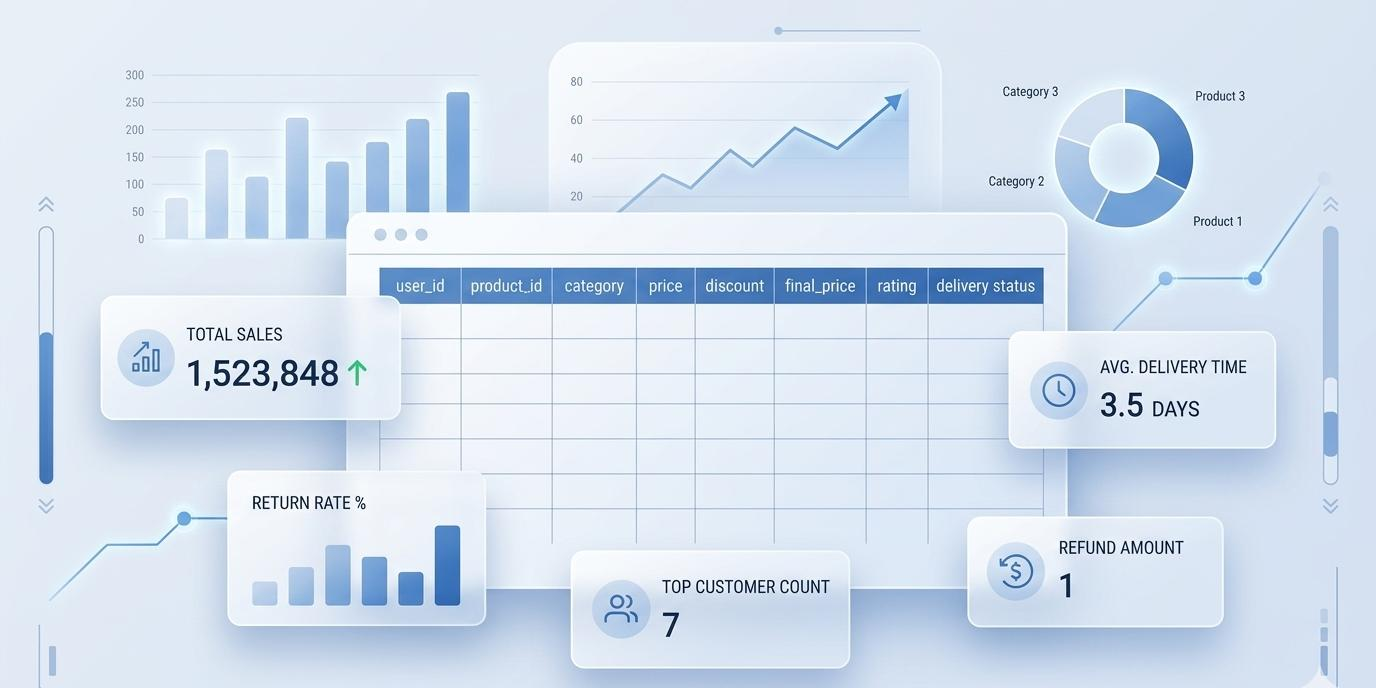

In [1]:
from IPython.display import Image, display
display(Image(r"c:\Users\ssa\OneDrive\Pictures\Amazon image.jpeg",width=500))

# Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Load the Dataset

In [3]:
df = pd.read_csv("amazon_ecommerce_1M.csv")

df.head()

,user_id,product_id,category,subcategory,brand,price,discount,final_price,rating,review_count,stock,seller_id,seller_rating,purchase_date,shipping_time_days,location,device,payment_method,is_returned,delivery_status
0,U356787,P39256,Electronics,Mobile,H&M,33090.51,10.46,29629.31,4.9,43,71,S2679,4.3,2025-03-04,6,Bangalore,Tablet,UPI,True,Returned
1,U198246,P38657,Sports,Outdoor,Samsung,9368.97,5.32,8870.73,3.9,13,119,S9279,4.9,2025-12-12,1,Delhi,Tablet,UPI,True,Returned
2,U539898,P38893,Sports,Fitness,H&M,14756.85,26.00,10919.43,4.2,46,229,S5557,4.9,2024-04-25,1,Chennai,Mobile App,Credit Card,True,Returned
3,U325772,P54118,Beauty,Makeup,Sony,668.83,24.81,502.91,3.8,6,52,S2519,3.1,2025-12-18,2,Mumbai,Web,UPI,False,In Transit
4,U865179,P70217,Home,Decor,Sony,10881.29,48.63,5589.58,4.0,48,274,S3045,2.6,2024-05-16,5,Delhi,Web,UPI,False,Delayed


# Exploratory Data Analysis

In [4]:
df. shape
df.describe()
df.info()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   user_id             1000000 non-null  str    
 1   product_id          1000000 non-null  str    
 2   category            1000000 non-null  str    
 3   subcategory         1000000 non-null  str    
 4   brand               1000000 non-null  str    
 5   price               1000000 non-null  float64
 6   discount            1000000 non-null  float64
 7   final_price         1000000 non-null  float64
 8   rating              1000000 non-null  float64
 9   review_count        1000000 non-null  int64  
 10  stock               1000000 non-null  int64  
 11  seller_id           1000000 non-null  str    
 12  seller_rating       1000000 non-null  float64
 13  purchase_date       1000000 non-null  str    
 14  shipping_time_days  1000000 non-null  int64  
 15  location            1000000

user_id               0
product_id            0
category              0
subcategory           0
brand                 0
price                 0
discount              0
final_price           0
rating                0
review_count          0
stock                 0
seller_id             0
seller_rating         0
purchase_date         0
shipping_time_days    0
location              0
device                0
payment_method        0
is_returned           0
delivery_status       0
dtype: int64

# Convert Purchase_Date to Datetime

In [5]:
df["purchase_date"]= pd.to_datetime(df["purchase_date"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   user_id             1000000 non-null  str           
 1   product_id          1000000 non-null  str           
 2   category            1000000 non-null  str           
 3   subcategory         1000000 non-null  str           
 4   brand               1000000 non-null  str           
 5   price               1000000 non-null  float64       
 6   discount            1000000 non-null  float64       
 7   final_price         1000000 non-null  float64       
 8   rating              1000000 non-null  float64       
 9   review_count        1000000 non-null  int64         
 10  stock               1000000 non-null  int64         
 11  seller_id           1000000 non-null  str           
 12  seller_rating       1000000 non-null  float64       
 13  purchase_date       1000

# Convert Categorical Columns

In [6]:
cat_cols= [
    "category","subcategory","brand",
    "location","device","payment_method",
    "delivery_status"
]
for col in cat_cols:
    df[col] = df[col].astype("category")

df.info()     

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 20 columns):
 #   Column              Non-Null Count    Dtype         
---  ------              --------------    -----         
 0   user_id             1000000 non-null  str           
 1   product_id          1000000 non-null  str           
 2   category            1000000 non-null  category      
 3   subcategory         1000000 non-null  category      
 4   brand               1000000 non-null  category      
 5   price               1000000 non-null  float64       
 6   discount            1000000 non-null  float64       
 7   final_price         1000000 non-null  float64       
 8   rating              1000000 non-null  float64       
 9   review_count        1000000 non-null  int64         
 10  stock               1000000 non-null  int64         
 11  seller_id           1000000 non-null  str           
 12  seller_rating       1000000 non-null  float64       
 13  purchase_date       1000

# Overall Return Rate

In [7]:
return_rate =df["is_returned"].mean()*100
print(f"Overall Return Rate: {return_rate:.2f}%")

Overall Return Rate: 11.60%


# Return rate by category

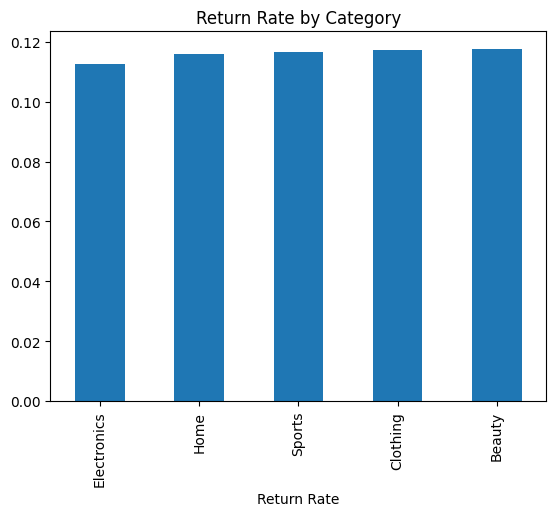

In [9]:
returns_by_category= df.groupby("category")["is_returned"].mean().sort_values()
returns_by_category.plot(kind="bar")
plt.title("Return Rate by Category")
plt.xlabel("Return Rate")
plt.show()

## Insight: Return Behavior by category
**Beauty products show the highest return rates compared to other products
-This could suggest issues such as:
-Product expectations not matching reality(shades, texture,effect)
-Customer dissatisfaction after purchase
**Beauty products required stronger product descriptions, reviews, and better recommendation targeting

# Pricing and Discount Analysis

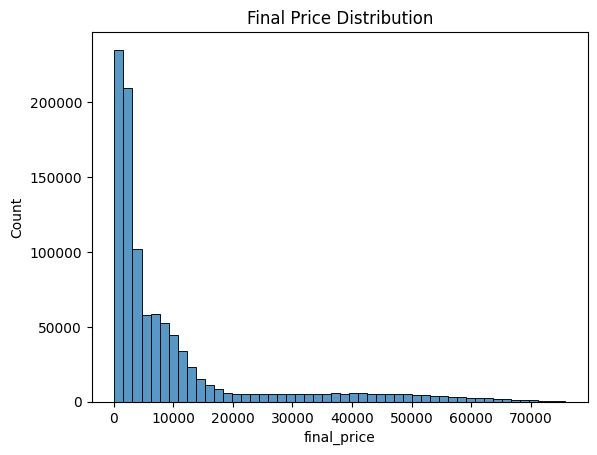

In [10]:
sns.histplot(df["final_price"],bins=50)
plt.title("Final Price Distribution")
plt.show()

## Insight: Price Distribution
-Most transactions are concentrated in lower to mid price ranges
-High priced purchases are relatively rare
-This indicates that platfrom is driven more by mass-market products than premium products

# Discount Impact Performance

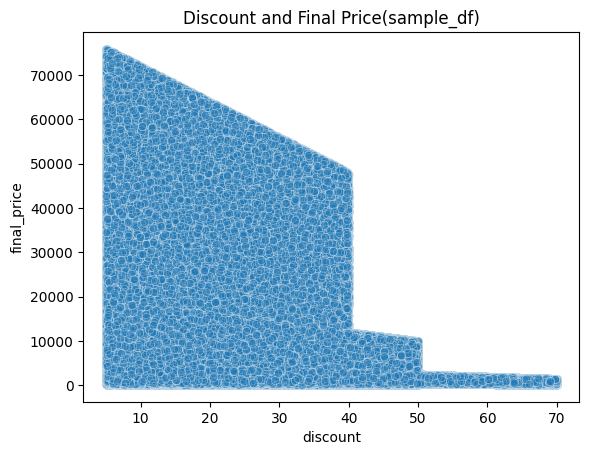

In [16]:
sample_df = df.sample(5000,random_state=42)
sns.scatterplot(x="discount", y="final_price",data=df, alpha=0.4)
plt.title("Discount and Final Price(sample_df)")
plt.show()

## Discount and Final Price 
-Higher discounts generally need to lower prices

# Delivery Performance

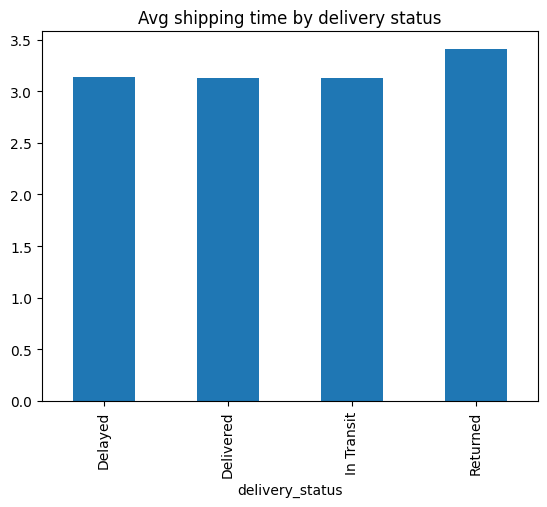

In [17]:
df.groupby("delivery_status")["shipping_time_days"].mean().plot(kind="bar")
plt.title("Avg shipping time by delivery status")
plt.show()

# Delivery Performance Insight
-A noticeable pattern shows that returns are more frequent when seller ratings are around 3.5
-suggesting a threshold where customer trust begins to drop